In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from matplotlib.patches import Patch

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:

data_path = os.path.join('..', 'data', 'student-mat.csv')

df = pd.read_csv(data_path, sep=';')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 395 rows, 33 columns


In [3]:

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:

print("Columns:", list(df.columns))

Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [5]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:

missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found")

Missing values per column:
No missing values found


In [7]:

df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [8]:

df = df.drop(columns=['G2'])
print(f"G2 dropped. New shape: {df.shape}")

G2 dropped. New shape: (395, 32)


In [9]:

df['result'] = (df['G3'] >= 10).astype(int)

print(f"Pass (1): {df['result'].sum()} students")
print(f"Fail (0): {(df['result'] == 0).sum()} students")
print(f"Pass Rate: {df['result'].mean()*100:.1f}%")

Pass (1): 265 students
Fail (0): 130 students
Pass Rate: 67.1%


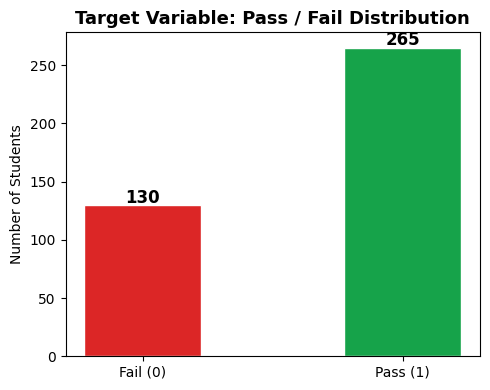

In [10]:

counts = df['result'].value_counts().sort_index()

plt.figure(figsize=(5, 4))
bars = plt.bar(['Fail (0)', 'Pass (1)'], counts.values,
               color=['#dc2626', '#16a34a'], edgecolor='white', width=0.45)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', fontweight='bold', fontsize=12)
plt.title('Target Variable: Pass / Fail Distribution', fontweight='bold', fontsize=13)
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

In [11]:

binary_cols = [
    'school', 'sex', 'address', 'famsize', 'Pstatus',
    'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic'
]

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print("Binary columns encoded:", binary_cols)

Binary columns encoded: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [13]:

multi_cols = ['Mjob', 'Fjob', 'reason', 'guardian']

for col in multi_cols:
    df[col] = le.fit_transform(df[col])

print("Multi-class columns encoded:", multi_cols)
print("\nEncoding complete!")

Multi-class columns encoded: ['Mjob', 'Fjob', 'reason', 'guardian']

Encoding complete!


In [14]:

print("Dataset after preprocessing — key columns + result:")
df[['age', 'G1', 'failures', 'higher', 'G3', 'result']].head(10)

Dataset after preprocessing — key columns + result:


,age,G1,failures,higher,G3,result
0,18,5,0,1,6,0
1,17,5,0,1,6,0
2,15,7,3,1,10,1
3,15,15,0,1,15,1
4,16,6,0,1,10,1
5,16,15,0,1,15,1
6,16,12,0,1,11,1
7,17,6,0,1,6,0
8,15,16,0,1,19,1
9,15,14,0,1,15,1


In [15]:

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G3,result
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,0
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,6,0
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,10,1
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,15,1
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,1


In [16]:

cleaned_path = os.path.join('..', 'data', 'cleaned_student_data.csv')
df.to_csv(cleaned_path, index=False)

print(f"Cleaned CSV saved to: {cleaned_path}")

# Verify by reloading
verify = pd.read_csv(cleaned_path)
print(f"Verified — Shape: {verify.shape}")
verify.head()

Cleaned CSV saved to: ..\data\cleaned_student_data.csv
Verified — Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G3,result
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,0
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,6,0
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,10,1
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,15,1
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,1


In [17]:


corr_matrix = df.corr()
target_corr = corr_matrix['result'].drop(['result', 'G3']).abs().sort_values(ascending=False)

print("Correlation with target (result) — sorted descending:")
print(target_corr)

Correlation with target (result) — sorted descending:
G1            0.664979
failures      0.337731
goout         0.183399
age           0.179645
higher        0.157708
Medu          0.115396
Fedu          0.108057
guardian      0.101407
schoolsup     0.099860
reason        0.099300
romantic      0.097737
paid          0.092665
absences      0.092244
studytime     0.074613
sex           0.070618
health        0.065668
internet      0.061791
famsup        0.059219
Dalc          0.057343
address       0.052282
famrel        0.046683
traveltime    0.044446
Pstatus       0.044050
famsize       0.041842
school        0.031254
Walc          0.029957
Fjob          0.028309
Mjob          0.026592
freetime      0.018321
activities    0.012414
nursery       0.008784
Name: result, dtype: float64


In [18]:


selected_features = target_corr[target_corr > 0.1].index.tolist()

if 'G1' not in selected_features:
    selected_features.append('G1')

print(f"Selected {len(selected_features)} features (correlation > 0.1):")
for i, f in enumerate(selected_features, 1):
    print(f"  {i}. {f:12s}  corr = {target_corr[f]:.4f}")

Selected 8 features (correlation > 0.1):
  1. G1            corr = 0.6650
  2. failures      corr = 0.3377
  3. goout         corr = 0.1834
  4. age           corr = 0.1796
  5. higher        corr = 0.1577
  6. Medu          corr = 0.1154
  7. Fedu          corr = 0.1081
  8. guardian      corr = 0.1014


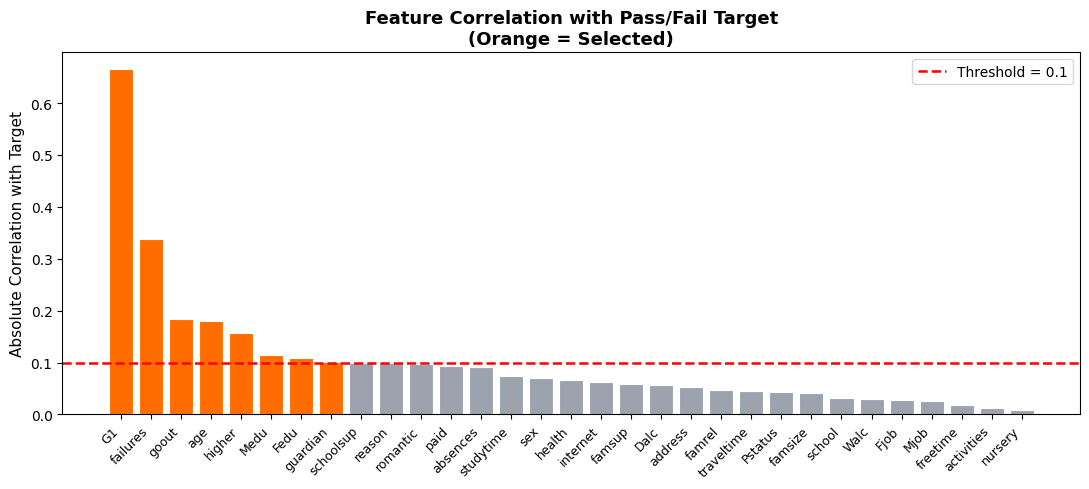

In [19]:
# Feature correlation bar chart with threshold line
plt.figure(figsize=(11, 5))
bar_colors = ['#FF6D00' if c > 0.1 else '#9ca3af' for c in target_corr.values]
plt.bar(target_corr.index, target_corr.values, color=bar_colors, edgecolor='white', linewidth=0.8)
plt.axhline(y=0.1, color='red', linestyle='--', linewidth=1.8, label='Threshold = 0.1')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Absolute Correlation with Target', fontsize=11)
plt.title('Feature Correlation with Pass/Fail Target\n(Orange = Selected)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

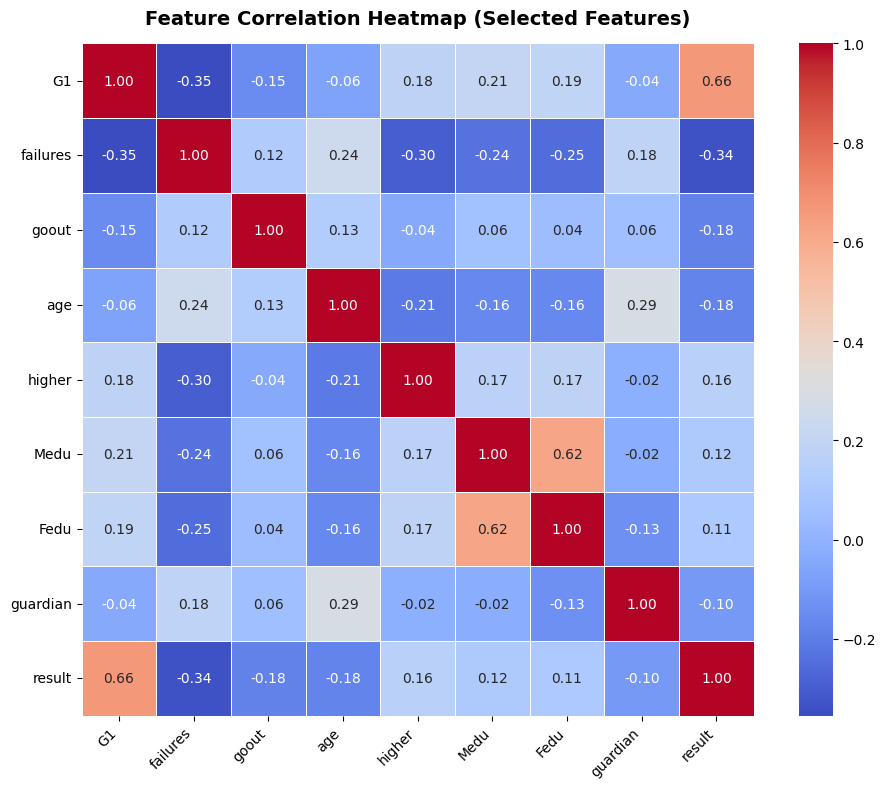

Heatmap saved.


In [20]:

plt.figure(figsize=(10, 8))
sns.heatmap(
    df[selected_features + ['result']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, square=True, annot_kws={'size': 10}
)
plt.title('Feature Correlation Heatmap (Selected Features)', fontsize=14, fontweight='bold', pad=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save heatmap for Flask static
plots_dir = os.path.join('..', 'static', 'plots')
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, 'heatmap.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Heatmap saved.")

In [21]:


X = df[selected_features]
y = df['result']

print(f"Feature Matrix X shape: {X.shape}")
print(f"Target Vector  y shape: {y.shape}")
print(f"Features: {selected_features}")

Feature Matrix X shape: (395, 8)
Target Vector  y shape: (395,)
Features: ['G1', 'failures', 'goout', 'age', 'higher', 'Medu', 'Fedu', 'guardian']


In [22]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")
print(f"\nTrain — Pass: {y_train.sum()}, Fail: {(y_train==0).sum()}")
print(f"Test  — Pass: {y_test.sum()},  Fail: {(y_test==0).sum()}")

Training set  : 316 samples
Test set      : 79 samples

Train — Pass: 212, Fail: 104
Test  — Pass: 53,  Fail: 26


In [23]:


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   
X_test_sc  = scaler.transform(X_test)         

print(f"X_train_sc shape : {X_train_sc.shape}")
print(f"X_test_sc  shape : {X_test_sc.shape}")
print("\n Scaling done (StandardScaler)")

X_train_sc shape : (316, 8)
X_test_sc  shape : (79, 8)

 Scaling done (StandardScaler)


In [24]:


models = {
    'SVM':           SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'KNN':           KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'Naive Bayes':   GaussianNB()
}

results = {}

print(f"{'Model':<15} | {'Accuracy':>8} | {'Precision':>9} | {'Recall':>6} | {'F1':>6}")
print('-' * 56)

for name, clf in models.items():
    # Train
    clf.fit(X_train_sc, y_train)
    # Predict
    y_pred = clf.predict(X_test_sc)
    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        'model': clf, 'accuracy': acc,
        'precision': prec, 'recall': rec,
        'f1': f1, 'y_pred': y_pred
    }
    print(f"{name:<15} | {acc*100:>7.2f}% | {prec*100:>8.2f}% | {rec*100:>5.2f}% | {f1*100:>5.2f}%")

Model           | Accuracy | Precision | Recall |     F1
--------------------------------------------------------
SVM             |   83.54% |    88.46% | 86.79% | 87.62%
KNN             |   77.22% |    79.66% | 88.68% | 83.93%
Random Forest   |   77.22% |    85.71% | 79.25% | 82.35%
Naive Bayes     |   75.95% |    78.33% | 88.68% | 83.19%


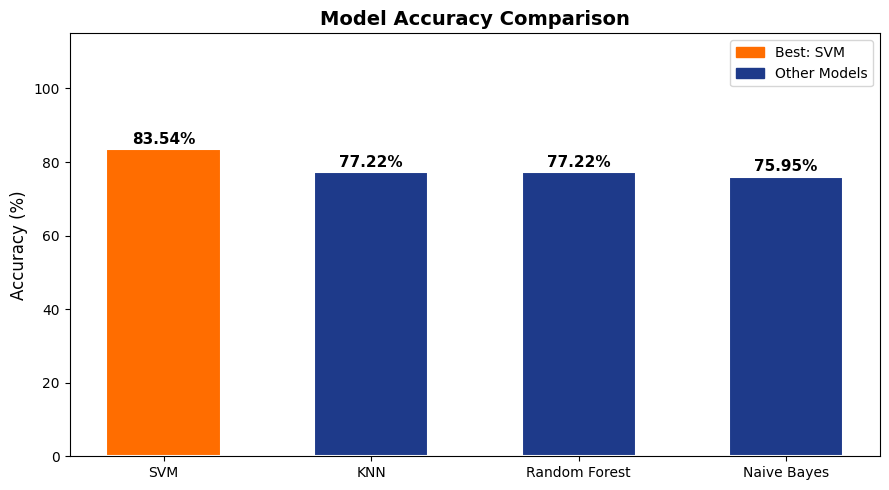

Accuracy chart saved.


In [25]:

best_name = max(results, key=lambda k: results[k]['accuracy'])

model_names = list(results.keys())
accuracies  = [results[k]['accuracy']  * 100 for k in model_names]
precisions  = [results[k]['precision'] * 100 for k in model_names]
recalls     = [results[k]['recall']    * 100 for k in model_names]
f1_scores   = [results[k]['f1']        * 100 for k in model_names]

# ---- Accuracy Bar Chart (same as train_model.py) ----
plt.figure(figsize=(9, 5))
colors = ['#FF6D00' if k == best_name else '#1E3A8A' for k in model_names]
bars = plt.bar(model_names, accuracies, color=colors,
               edgecolor='white', linewidth=1.5, width=0.55)
plt.ylim(0, 115)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=11)
plt.legend(handles=[
    Patch(color='#FF6D00', label=f'Best: {best_name}'),
    Patch(color='#1E3A8A', label='Other Models')
])
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'accuracy_chart.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Accuracy chart saved.")

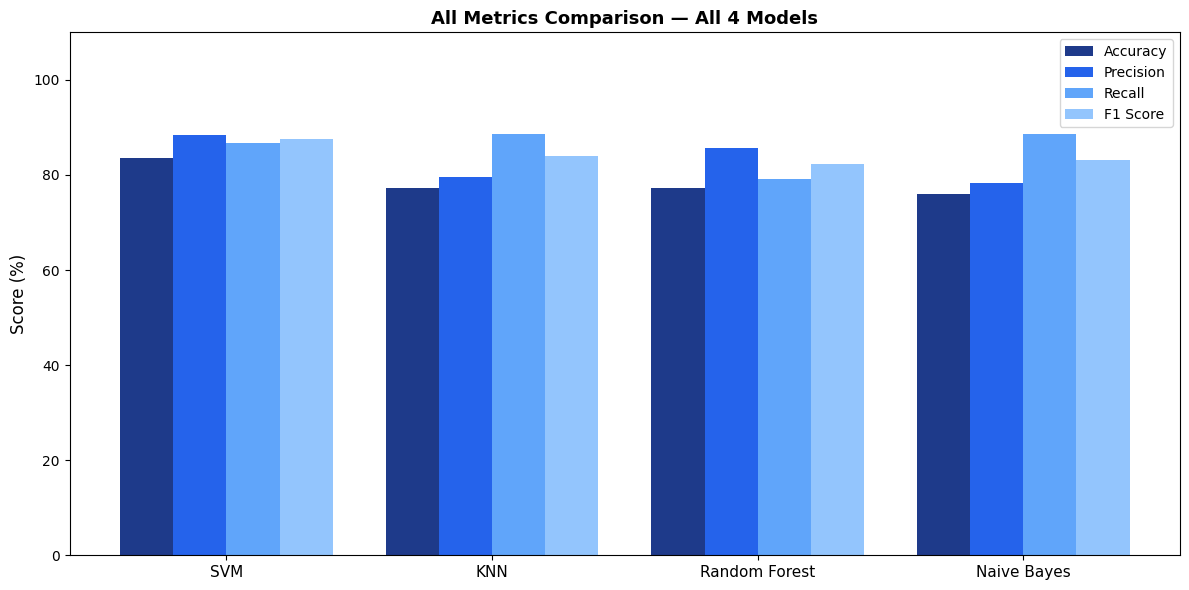

In [26]:

x = np.arange(len(model_names))
w = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*w, accuracies,  w, label='Accuracy',  color='#1E3A8A')
ax.bar(x - 0.5*w, precisions,  w, label='Precision', color='#2563EB')
ax.bar(x + 0.5*w, recalls,     w, label='Recall',    color='#60a5fa')
ax.bar(x + 1.5*w, f1_scores,   w, label='F1 Score',  color='#93c5fd')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 110)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('All Metrics Comparison — All 4 Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [27]:


best_name  = max(results, key=lambda k: results[k]['accuracy'])
best_acc   = results[best_name]['accuracy']
best_model = results[best_name]['model']
best_pred  = results[best_name]['y_pred']

print("=" * 50)
print(f"  Best Model  : {best_name}")
print(f"  Accuracy    : {best_acc*100:.2f}%")
print(f"  Precision   : {results[best_name]['precision']*100:.2f}%")
print(f"  Recall      : {results[best_name]['recall']*100:.2f}%")
print(f"  F1 Score    : {results[best_name]['f1']*100:.2f}%")
print("=" * 50)
print(f"\nBest Model: {best_name} | Accuracy: {best_acc*100:.2f}%")

  Best Model  : SVM
  Accuracy    : 83.54%
  Precision   : 88.46%
  Recall      : 86.79%
  F1 Score    : 87.62%

Best Model: SVM | Accuracy: 83.54%


In [28]:


print(f"Classification Report ({best_name}):")
print("=" * 50)
print(classification_report(y_test, best_pred, target_names=['Fail', 'Pass']))

Classification Report (SVM):
              precision    recall  f1-score   support

        Fail       0.74      0.77      0.75        26
        Pass       0.88      0.87      0.88        53

    accuracy                           0.84        79
   macro avg       0.81      0.82      0.82        79
weighted avg       0.84      0.84      0.84        79



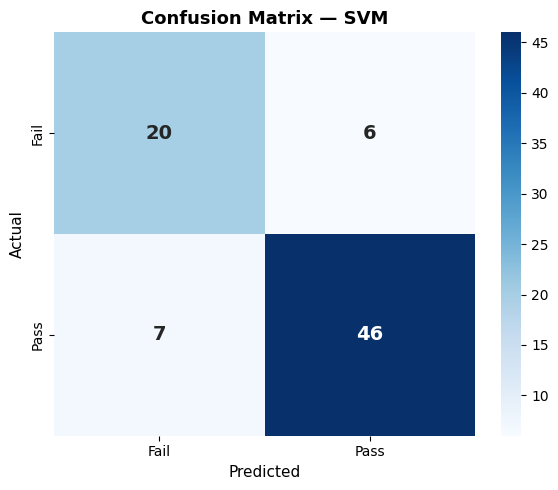

TN (Correct Fail)   : 20
FP (Wrong Pass)     : 6
FN (Wrong Fail)     : 7
TP (Correct Pass)   : 46
Confusion matrix saved.


In [29]:


cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Fail', 'Pass'],
    yticklabels=['Fail', 'Pass'],
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.ylabel('Actual', fontsize=11)
plt.xlabel('Predicted', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'confusion_matrix.png'), dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN (Correct Fail)   : {tn}")
print(f"FP (Wrong Pass)     : {fp}")
print(f"FN (Wrong Fail)     : {fn}")
print(f"TP (Correct Pass)   : {tp}")
print("Confusion matrix saved.")

In [31]:


model_dir = os.path.join('..', 'models')
os.makedirs(model_dir, exist_ok=True)

model_path    = os.path.join(model_dir, 'best_model.pkl')
scaler_path   = os.path.join(model_dir, 'scaler.pkl')
features_path = os.path.join(model_dir, 'features.pkl')

pickle.dump(best_model,        open(model_path,    'wb'))
pickle.dump(scaler,            open(scaler_path,   'wb'))
pickle.dump(selected_features, open(features_path, 'wb'))

print(f"Model saved   : {model_path}")
print(f"Scaler saved  : {scaler_path}")
print(f"Features saved: {features_path}")

Model saved   : ..\models\best_model.pkl
Scaler saved  : ..\models\scaler.pkl
Features saved: ..\models\features.pkl


In [32]:

loaded_model    = pickle.load(open(model_path,    'rb'))
loaded_scaler   = pickle.load(open(scaler_path,   'rb'))
loaded_features = pickle.load(open(features_path, 'rb'))

y_verify = loaded_model.predict(loaded_scaler.transform(X_test))
verify_acc = accuracy_score(y_test, y_verify)

print(f"Loaded model accuracy  : {verify_acc*100:.2f}%")
print(f"Loaded features        : {loaded_features}")
print("\nModel verified and ready for Flask API!")

Loaded model accuracy  : 83.54%
Loaded features        : ['G1', 'failures', 'goout', 'age', 'higher', 'Medu', 'Fedu', 'guardian']

Model verified and ready for Flask API!


In [33]:
def predict_student(feature_dict: dict) -> dict:
    """
    Predict student pass/fail.
    Args   : feature_dict — dict with selected feature names as keys
    Returns: dict with prediction (0/1), label (Pass/Fail), confidence (%)
    """
    loaded_model    = pickle.load(open(model_path,    'rb'))
    loaded_scaler   = pickle.load(open(scaler_path,   'rb'))
    loaded_features = pickle.load(open(features_path, 'rb'))

    values   = [feature_dict[f] for f in loaded_features]
    input_df = pd.DataFrame([values], columns=loaded_features)
    scaled   = loaded_scaler.transform(input_df)
    pred     = loaded_model.predict(scaled)[0]
    proba    = loaded_model.predict_proba(scaled)[0]

    return {
        'prediction': int(pred),
        'label':      'Pass' if pred == 1 else 'Fail',
        'confidence': float(max(proba)) * 100
    }

print("Predictor function defined")

Predictor function defined


In [34]:
sample   = {feat: float(X_test.iloc[0][feat]) for feat in selected_features}
test_res = predict_student(sample)
actual   = 'Pass' if y_test.iloc[0] == 1 else 'Fail'

print(f"Sample features : {sample}")
print(f"Predicted       : {test_res['label']} ({test_res['confidence']:.1f}% confidence)")
print(f"Actual          : {actual}")

Sample features : {'G1': 14.0, 'failures': 1.0, 'goout': 3.0, 'age': 18.0, 'higher': 1.0, 'Medu': 2.0, 'Fedu': 4.0, 'guardian': 2.0}
Predicted       : Pass (74.9% confidence)
Actual          : Pass


In [35]:
print(f"{'#':<4} {'Actual':<8} {'Predicted':<10} {'Confidence':<12} {'Match'}")
print('-' * 44)
for i in range(5):
    s   = {feat: float(X_test.iloc[i][feat]) for feat in selected_features}
    res = predict_student(s)
    act = 'Pass' if y_test.iloc[i] == 1 else 'Fail'
    ok  = '✅' if res['label'] == act else '❌'
    print(f"{i+1:<4} {act:<8} {res['label']:<10} {res['confidence']:>8.1f}%   {ok}")

#    Actual   Predicted  Confidence   Match
--------------------------------------------
1    Pass     Pass           74.9%   ✅
2    Fail     Fail           64.1%   ✅
3    Pass     Pass           93.2%   ✅
4    Pass     Pass           88.8%   ✅
5    Pass     Pass           92.1%   ✅


In [36]:
print("=" * 60)
print("       PIPELINE COMPLETE — FINAL SUMMARY")
print("=" * 60)
print(f"  Dataset         : UCI Student Performance (Math)")
print(f"  Total Records   : {len(df)}")
print(f"  Features Used   : {len(selected_features)} (auto-selected via corr > 0.1)")
print(f"  Selected Feats  : {selected_features}")
print(f"  Target          : result  (Pass=1 if G3>=10, Fail=0)")
print(f"  Train/Test Split: 80% / 20%")
print()
print("  Model Results:")
for name, res in results.items():
    tag = '  <-- BEST ✅' if name == best_name else ''
    print(f"    {name:<15}: {res['accuracy']*100:.2f}%{tag}")
print()
print(f"  Best Model      : {best_name}")
print(f"  Final Accuracy  : {best_acc*100:.2f}%")
print(f"  Saved at        : {model_path}")
print("=" * 60)

       PIPELINE COMPLETE — FINAL SUMMARY
  Dataset         : UCI Student Performance (Math)
  Total Records   : 395
  Features Used   : 8 (auto-selected via corr > 0.1)
  Selected Feats  : ['G1', 'failures', 'goout', 'age', 'higher', 'Medu', 'Fedu', 'guardian']
  Target          : result  (Pass=1 if G3>=10, Fail=0)
  Train/Test Split: 80% / 20%

  Model Results:
    SVM            : 83.54%  <-- BEST ✅
    KNN            : 77.22%
    Random Forest  : 77.22%
    Naive Bayes    : 75.95%

  Best Model      : SVM
  Final Accuracy  : 83.54%
  Saved at        : ..\models\best_model.pkl
